# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [ ]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



In [ ]:
def display_cluster(X, km=None, num_clusters=0):
    color = 'brgcmyk'
    alpha = 0.5
    s = 20

    # If no clustering yet → plot raw data
    if num_clusters == 0 or km is None:
        plt.scatter(X[:,0], X[:,1], c='b', alpha=alpha, s=s)

    # If clustering exists → plot clusters + centroids
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_ == i, 0],
                        X[km.labels_ == i, 1],
                        c=color[i % len(color)],
                        alpha=alpha,
                        s=s)

            plt.scatter(km.cluster_centers_[i][0],
                        km.cluster_centers_[i][1],
                        c=color[i % len(color)],
                        marker='x',
                        s=100)

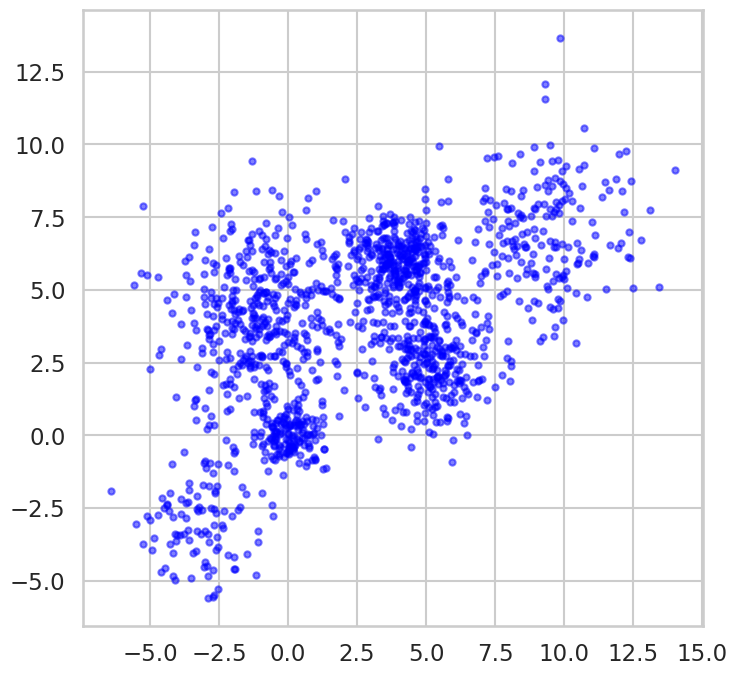

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

# Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]

Multi_blob_Data, y = make_blobs(
    n_samples=[100,150,300,400,300,200],
    n_features=2,
    cluster_std=[1.3,0.6,1.2,1.7,0.9,1.7],
    centers=centers,
    shuffle=False,
    random_state=42
)

display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

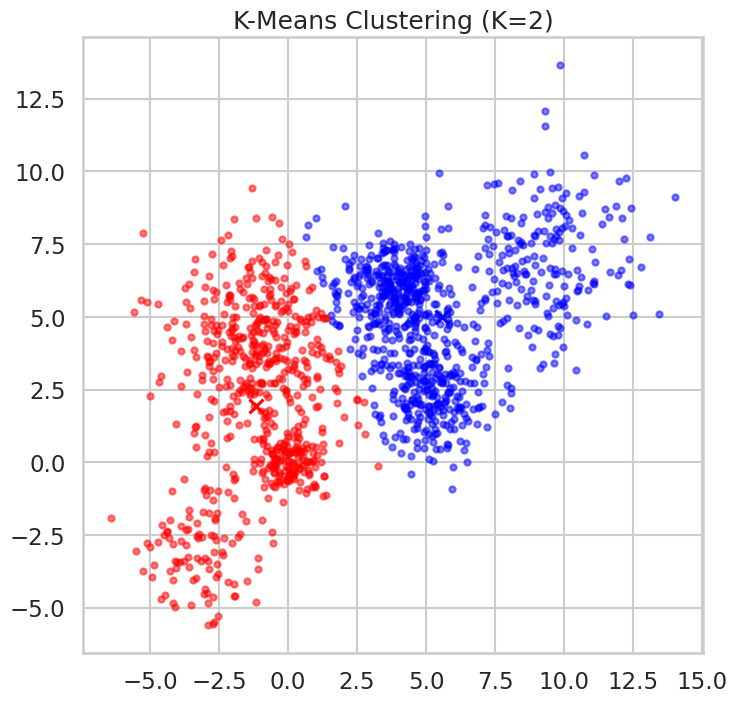

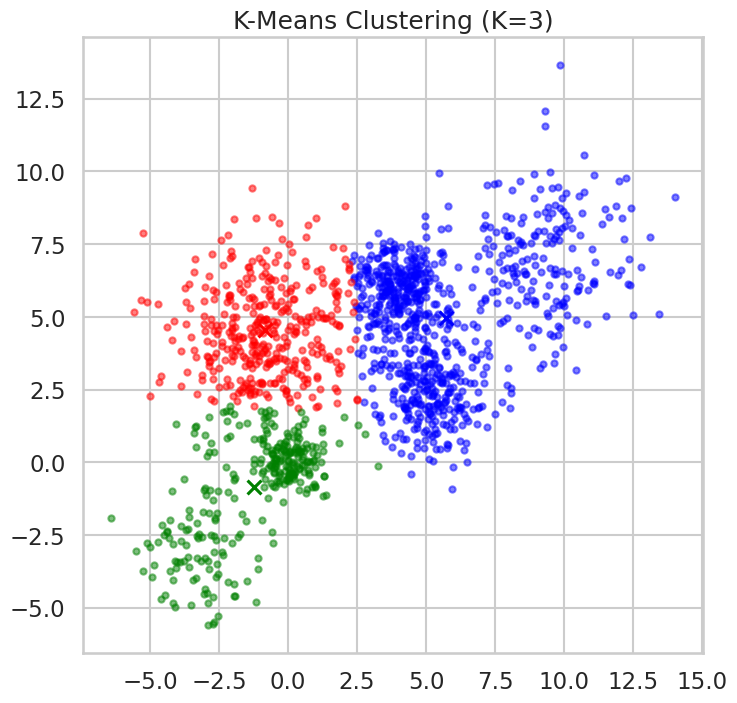

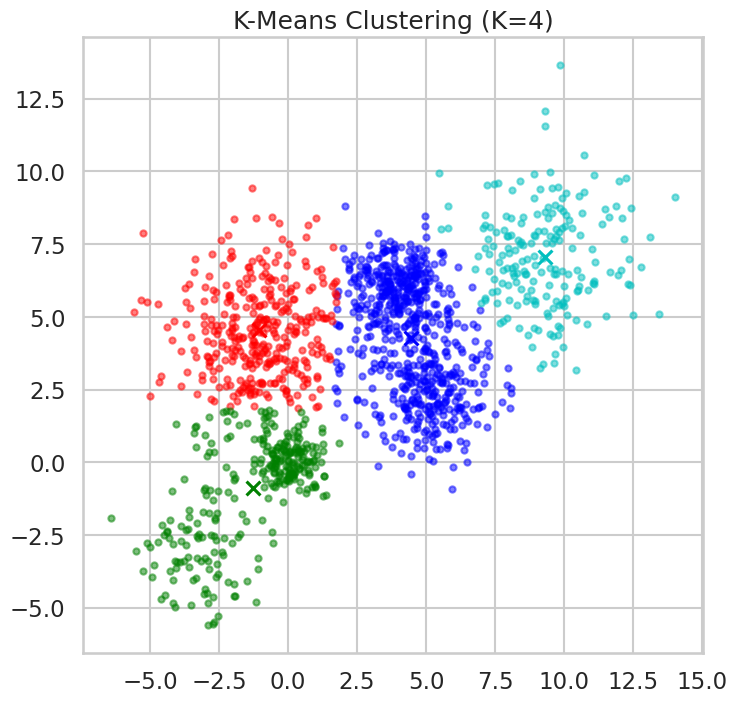

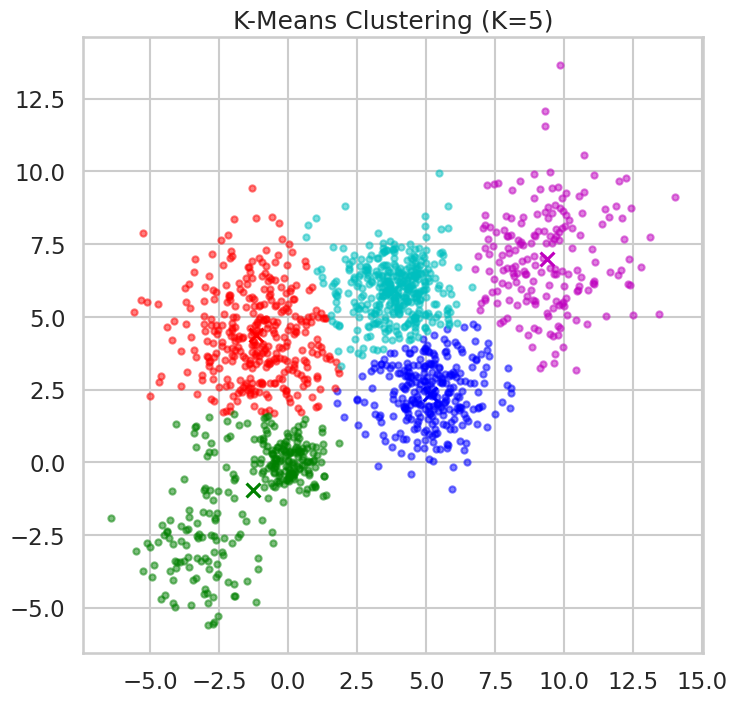

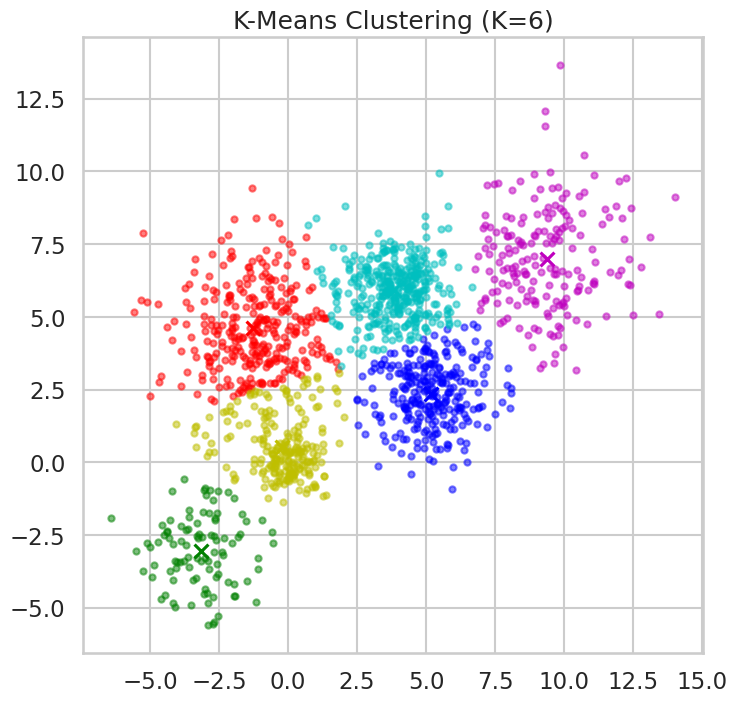

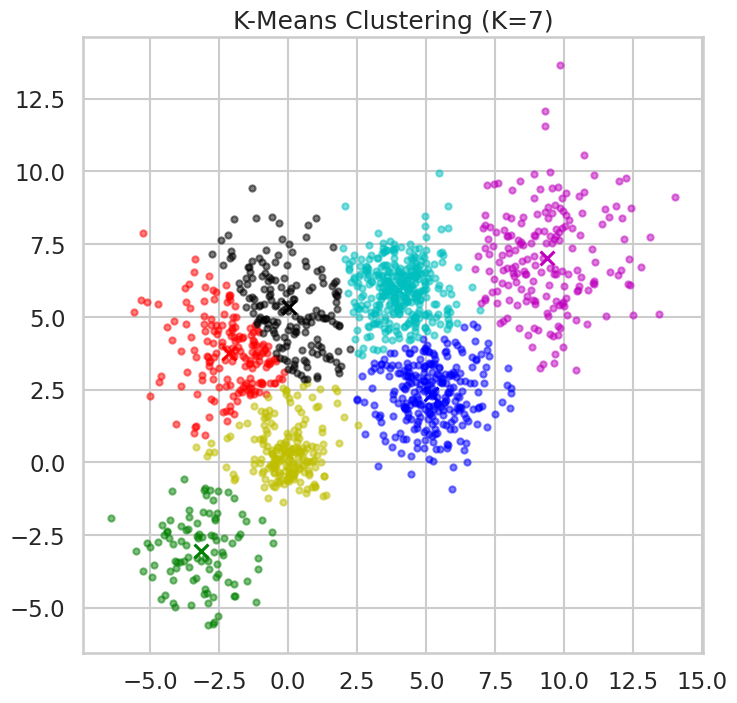

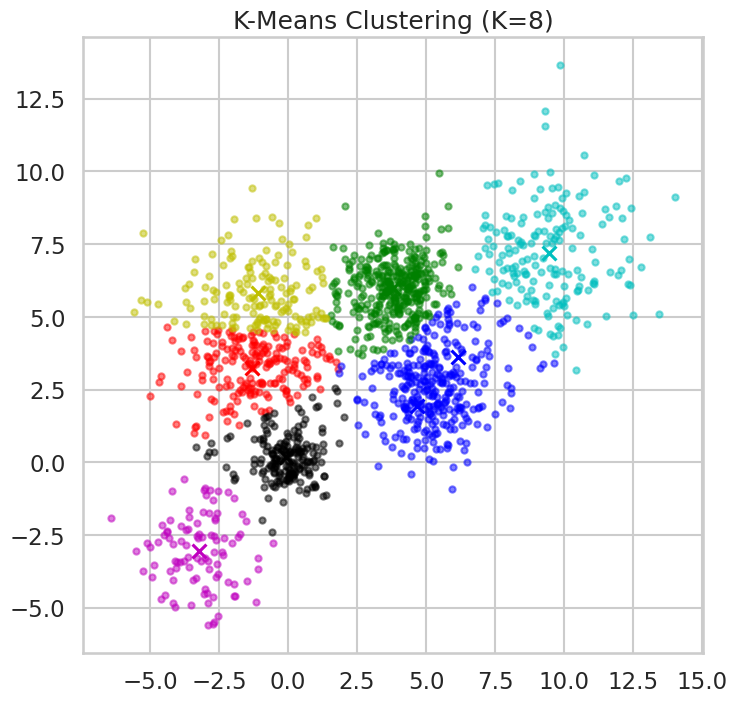

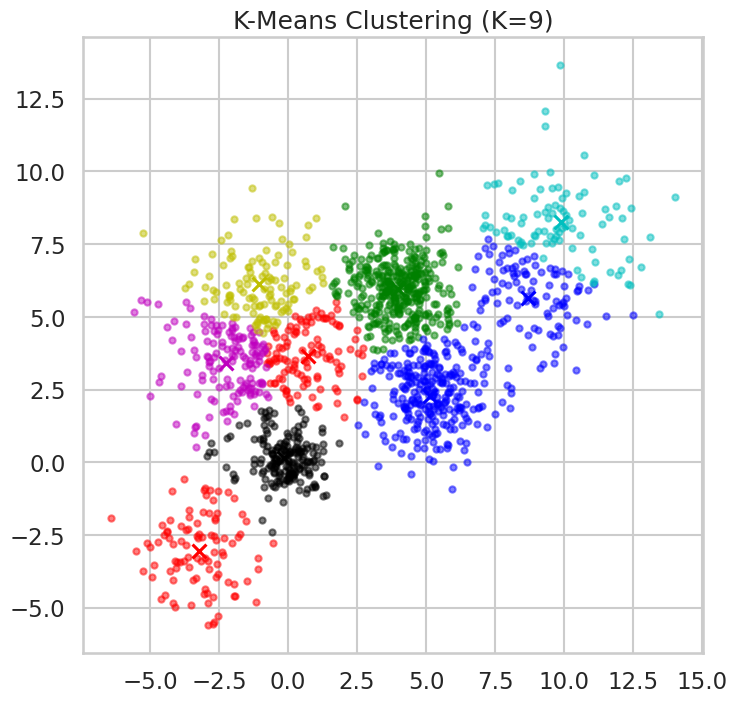

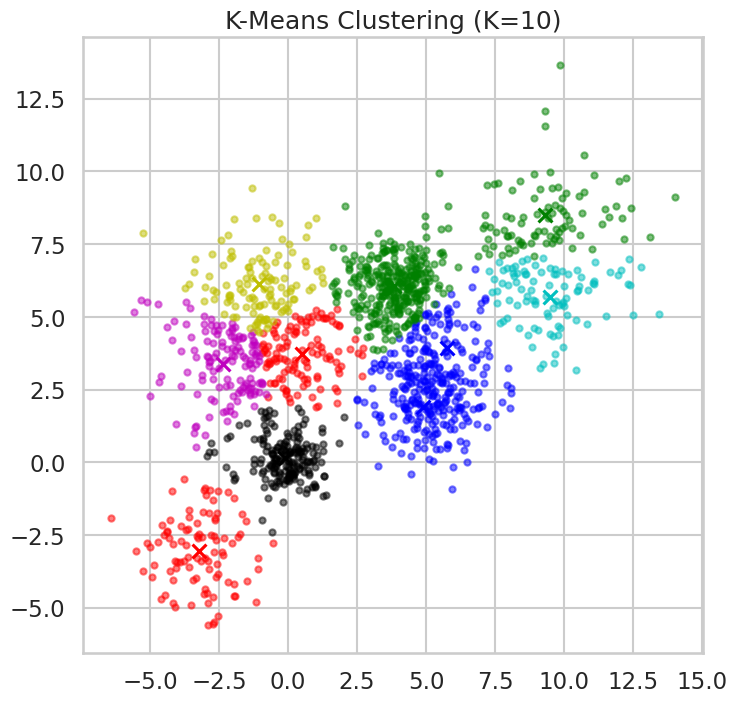

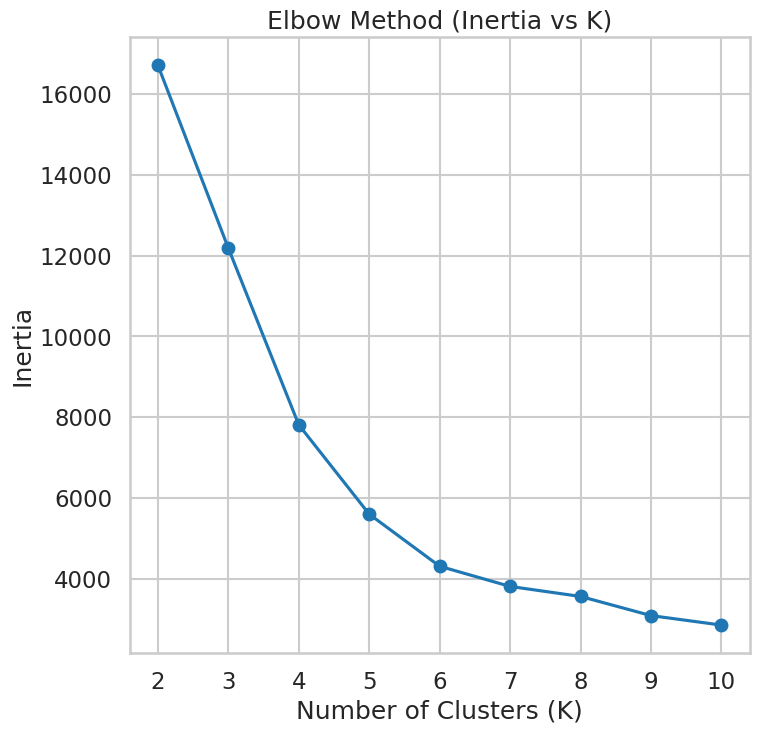

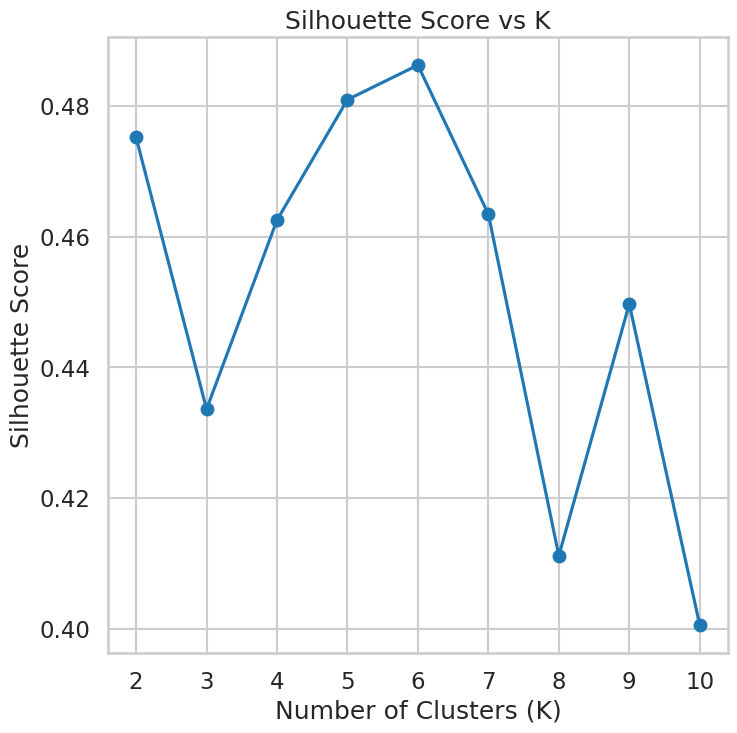

Best K based on silhouette score: 6
Best Silhouette Score: 0.4862240839323367


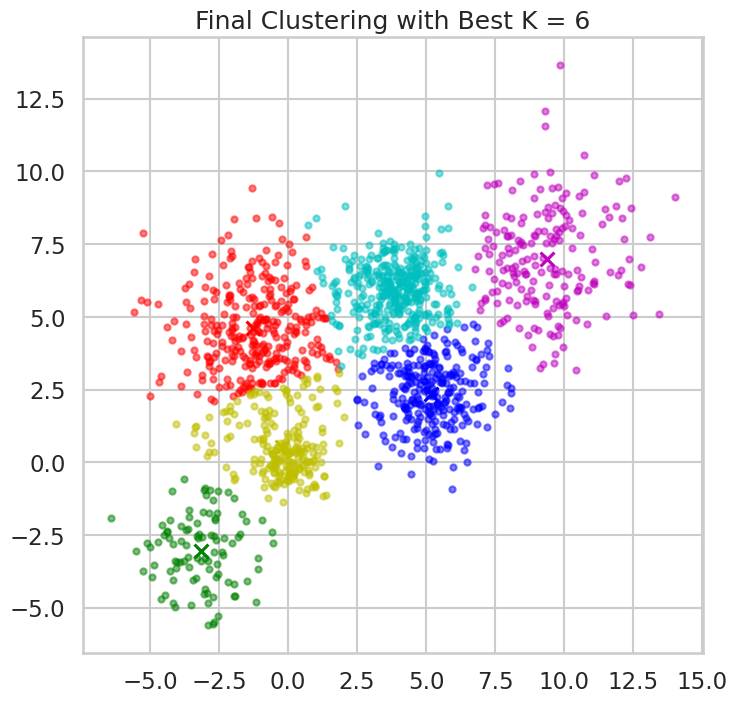

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of K values to test
K_values = range(2, 11)

# Lists to store results
inertia_list = []
silhouette_list = []

# Loop over different K values
for k in K_values:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(Multi_blob_Data)

    # Store inertia (distortion)
    inertia_list.append(km.inertia_)

    # Store silhouette score
    score = silhouette_score(Multi_blob_Data, labels)
    silhouette_list.append(score)

    # Display clusters
    plt.figure()
    plt.title(f"K-Means Clustering (K={k})")
    display_cluster(Multi_blob_Data, km, num_clusters=k)
    plt.show()


# Elbow Method (Inertia vs K)
plt.figure()
plt.plot(K_values, inertia_list, marker='o')
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


# 📈 Silhouette Score vs K
plt.figure()
plt.plot(K_values, silhouette_list, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()


# Find Best K based on Silhouette Score
best_k = list(K_values)[silhouette_list.index(max(silhouette_list))]
best_score = max(silhouette_list)

print(f"Best K based on silhouette score: {best_k}")
print(f"Best Silhouette Score: {best_score}")


# Final Clustering with Best K
best_km = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
best_labels = best_km.fit_predict(Multi_blob_Data)

plt.figure()
plt.title(f"Final Clustering with Best K = {best_k}")
display_cluster(Multi_blob_Data, best_km, num_clusters=best_k)
plt.show()

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

In [ ]:
def display_cluster(data, model, num_clusters):
    labels = model.labels_

    plt.scatter(data[:, 0], data[:, 1], c=labels)

    # Plot cluster centers if available (not always in hierarchical)
    if hasattr(model, "cluster_centers_"):
        centers = model.cluster_centers_
        plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='x')

Linkage: ward, Metric: euclidean, Silhouette Score: 0.4687


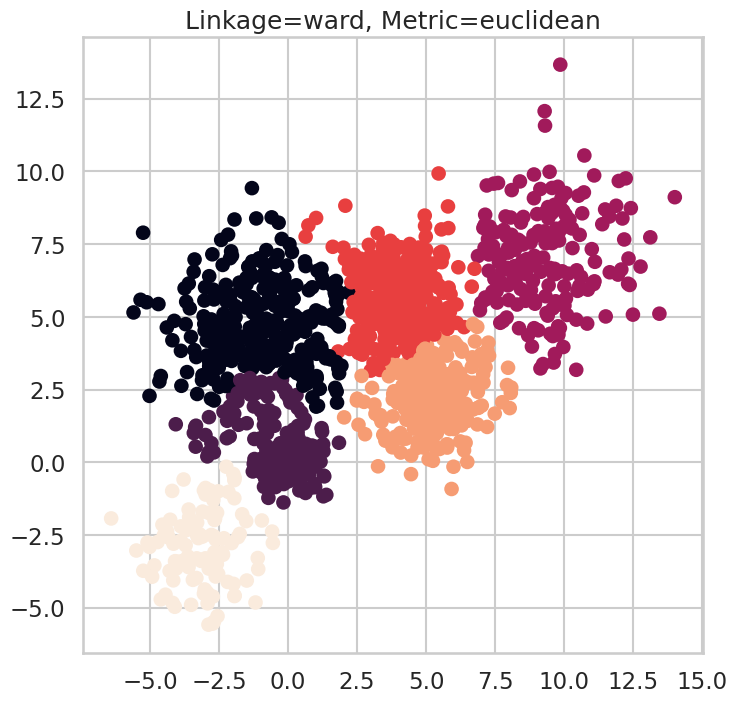

Linkage: complete, Metric: euclidean, Silhouette Score: 0.3819


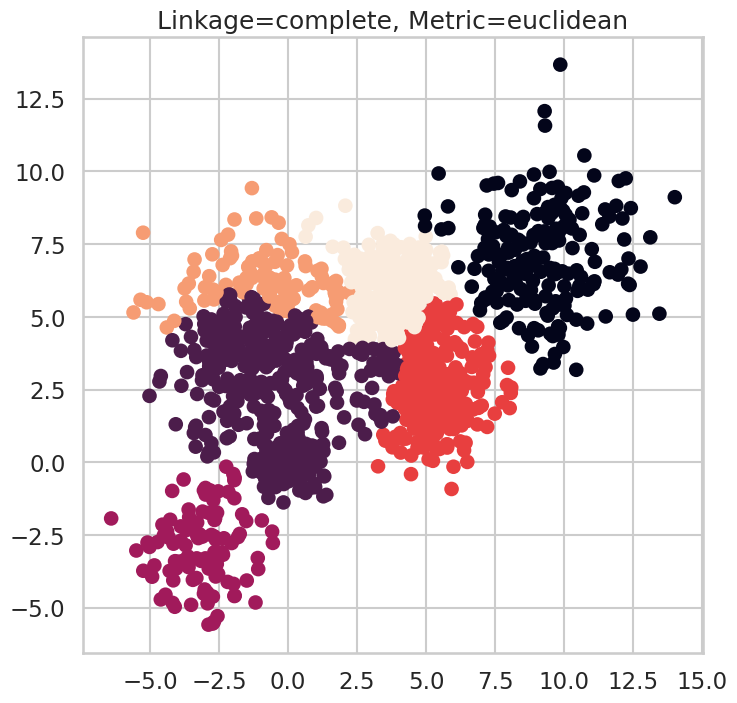

Linkage: complete, Metric: manhattan, Silhouette Score: 0.3370


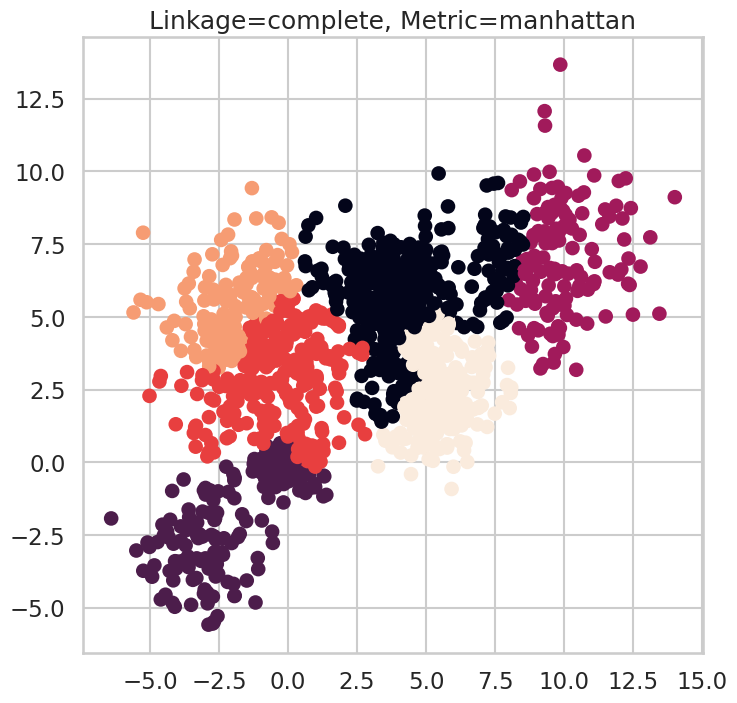

Linkage: complete, Metric: cosine, Silhouette Score: 0.1885


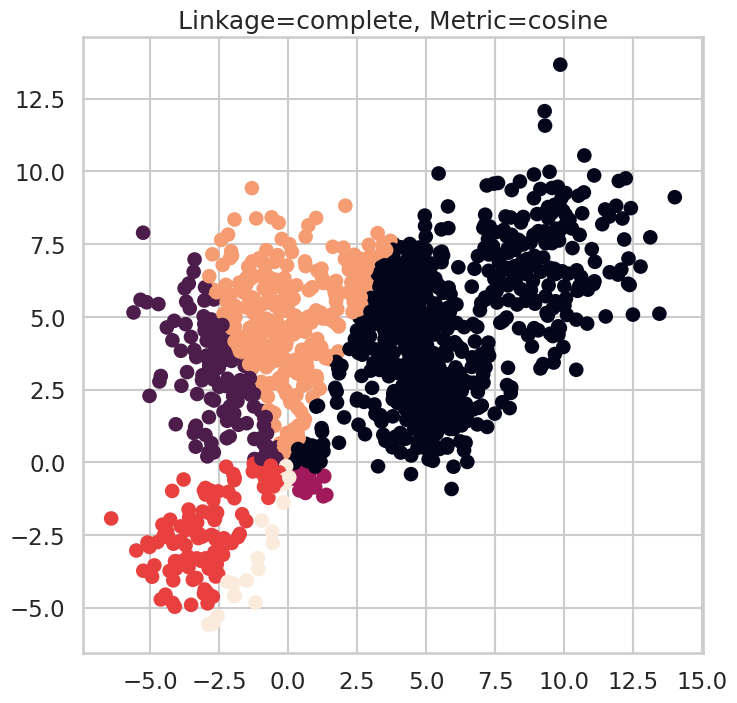

Linkage: average, Metric: euclidean, Silhouette Score: 0.4148


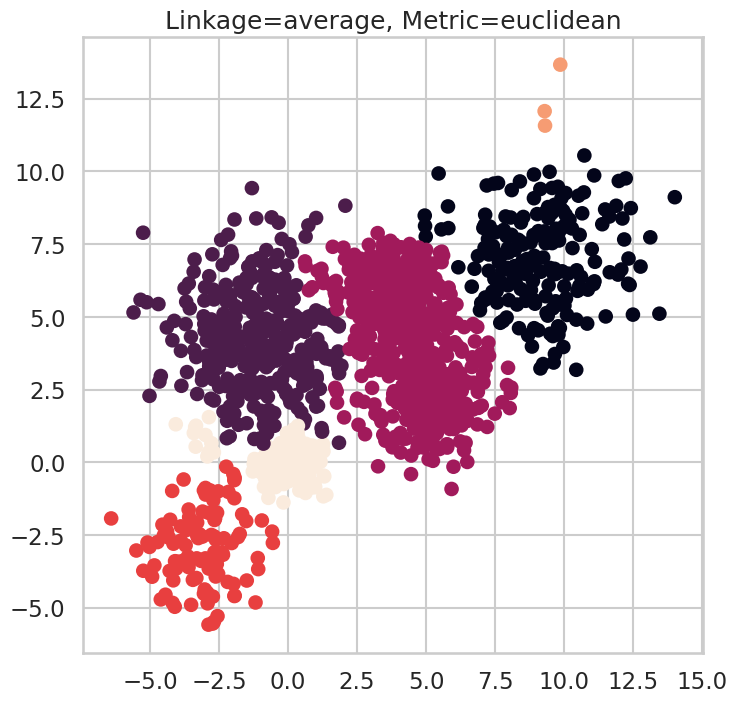

Linkage: average, Metric: manhattan, Silhouette Score: 0.3803


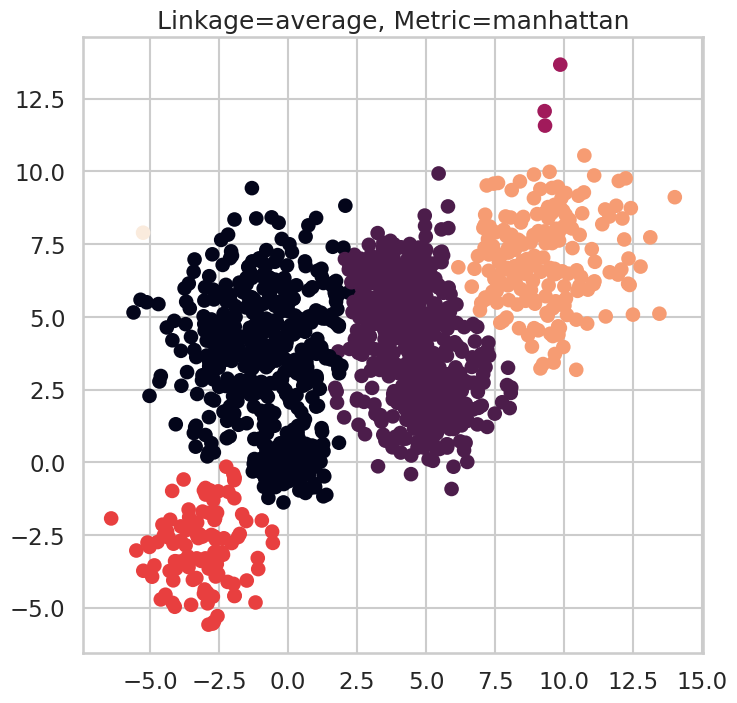

Linkage: average, Metric: cosine, Silhouette Score: 0.2036


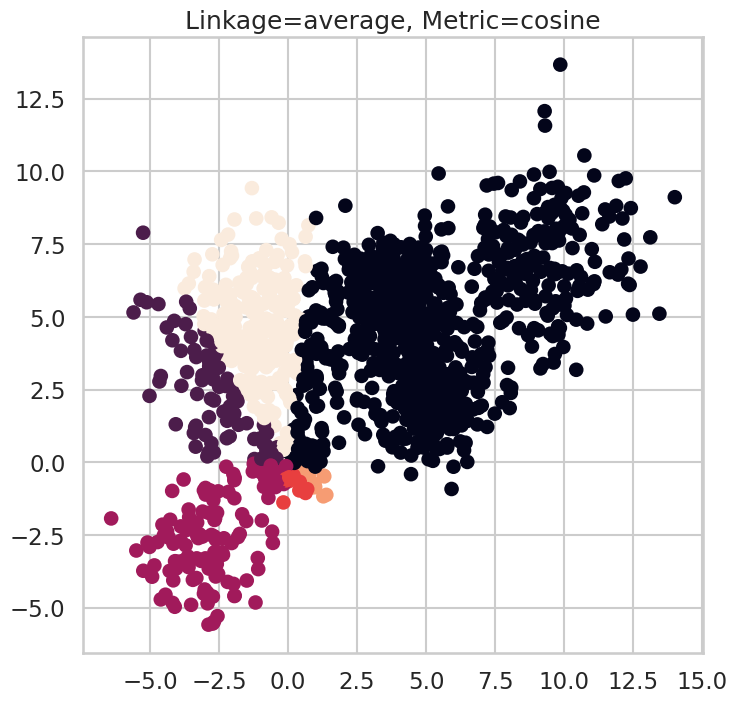


Best Parameters:
Linkage: ward
Metric: euclidean
Best Silhouette Score: 0.4687


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# PARAMETERS TO TEST
# -------------------------------
linkages = ['ward', 'complete', 'average']
metrics = ['euclidean', 'manhattan', 'cosine']

best_score = -1
best_params = None

results = []

# -------------------------------
# TRY DIFFERENT COMBINATIONS
# -------------------------------
for linkage_method in linkages:
    for metric in metrics:

        # Ward only works with Euclidean
        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        model = AgglomerativeClustering(
            n_clusters=6,
            metric=metric,
            linkage=linkage_method
        )

        labels = model.fit_predict(Multi_blob_Data)

        # Compute silhouette score
        score = silhouette_score(Multi_blob_Data, labels)
        results.append((linkage_method, metric, score))

        print(f"Linkage: {linkage_method}, Metric: {metric}, Silhouette Score: {score:.4f}")

        # Plot clustering result
        plt.figure()
        plt.title(f"Linkage={linkage_method}, Metric={metric}")
        display_cluster(Multi_blob_Data, model, num_clusters=6)
        plt.show()

        # Track best parameters
        if score > best_score:
            best_score = score
            best_params = (linkage_method, metric)

# -------------------------------
# BEST RESULT
# -------------------------------
print("\nBest Parameters:")
print(f"Linkage: {best_params[0]}")
print(f"Metric: {best_params[1]}")
print(f"Best Silhouette Score: {best_score:.4f}")

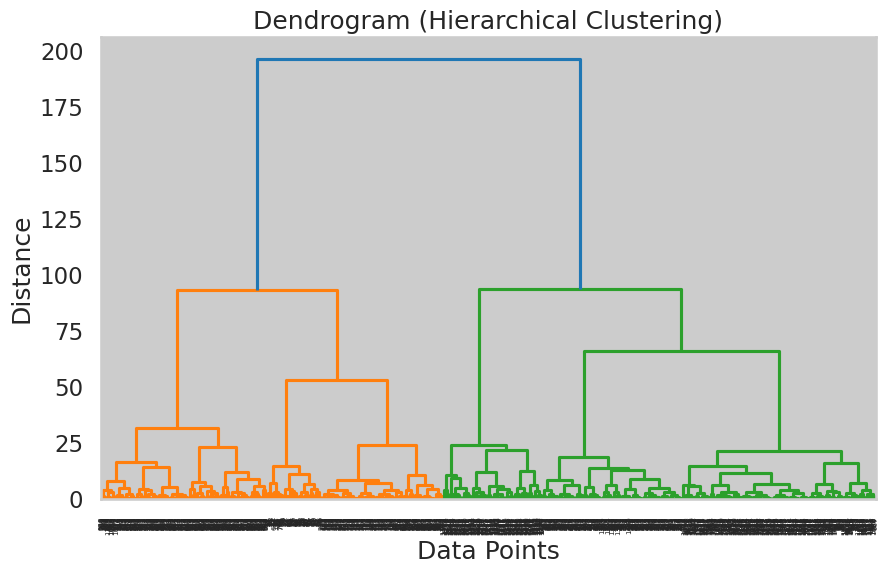

In [ ]:
# Using Ward linkage for dendrogram (best for visualization)
linked = linkage(Multi_blob_Data, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

EPS=0.10, MinSamples=5, Score=-0.5423
EPS=0.10, MinSamples=10, Score=-1.0000
EPS=0.10, MinSamples=15, Score=-1.0000
EPS=0.10, MinSamples=20, Score=-1.0000
EPS=0.10, MinSamples=25, Score=-1.0000
EPS=0.42, MinSamples=5, Score=-0.0208
EPS=0.42, MinSamples=10, Score=-0.0861
EPS=0.42, MinSamples=15, Score=-0.1399
EPS=0.42, MinSamples=20, Score=-0.2789
EPS=0.42, MinSamples=25, Score=-0.1566
EPS=0.74, MinSamples=5, Score=0.2385
EPS=0.74, MinSamples=10, Score=0.0910
EPS=0.74, MinSamples=15, Score=0.0895
EPS=0.74, MinSamples=20, Score=0.1979
EPS=0.74, MinSamples=25, Score=0.2044
EPS=1.07, MinSamples=5, Score=0.3996
EPS=1.07, MinSamples=10, Score=0.3724
EPS=1.07, MinSamples=15, Score=0.3483
EPS=1.07, MinSamples=20, Score=0.2408
EPS=1.07, MinSamples=25, Score=0.2187
EPS=1.39, MinSamples=5, Score=0.4532
EPS=1.39, MinSamples=10, Score=0.3996
EPS=1.39, MinSamples=15, Score=0.3881
EPS=1.39, MinSamples=20, Score=0.3978
EPS=1.39, MinSamples=25, Score=0.3981
EPS=1.71, MinSamples=5, Score=0.4376
EPS=1.71

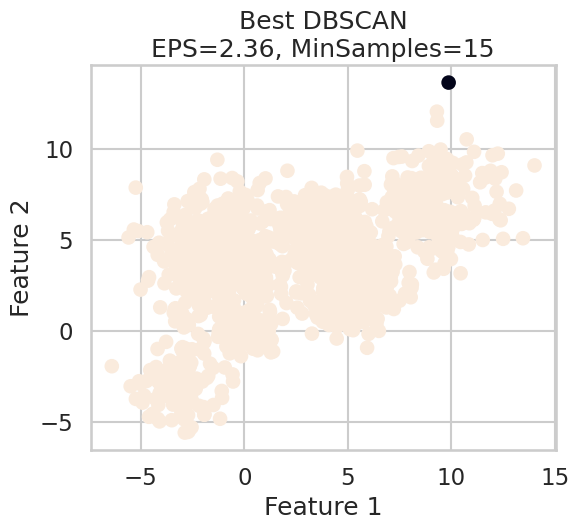

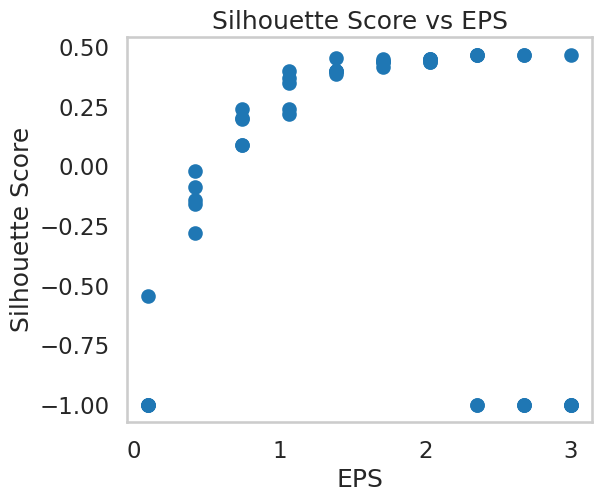

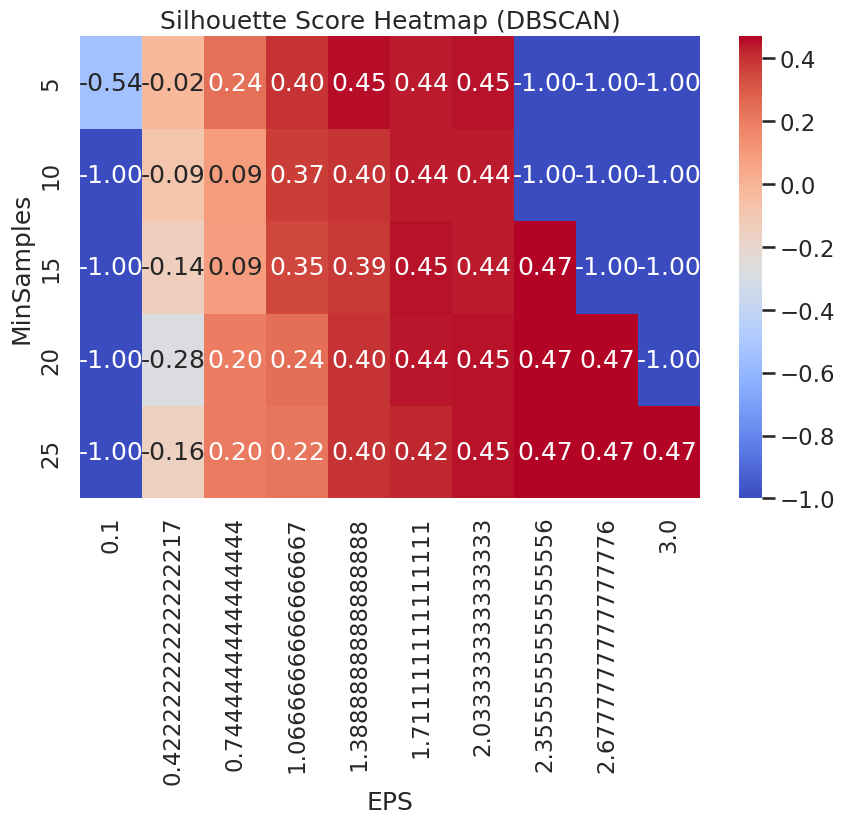

In [ ]:
# ===============================
# DBSCAN FULL IMPLEMENTATION
# ===============================

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. PARAMETERS
# -------------------------------
eps_values = np.linspace(0.1, 3, 10)        # EPS from 0.1 to 3
min_samples_values = range(5, 26, 5)        # Min_samples from 5 to 25

best_score = -1
best_params = None
results = []

# -------------------------------
# 2. GRID SEARCH
# -------------------------------
for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(Multi_blob_Data)

        unique_labels = set(labels)

        # Ignore cases with only 1 cluster or all noise
        if len(unique_labels) > 1 and len(unique_labels) < len(Multi_blob_Data):
            try:
                score = silhouette_score(Multi_blob_Data, labels)
            except:
                score = -1
        else:
            score = -1

        results.append((eps, min_samples, score))

        print(f"EPS={eps:.2f}, MinSamples={min_samples}, Score={score:.4f}")

        # Track best parameters
        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

# -------------------------------
# 3. BEST PARAMETERS
# -------------------------------
print("\n===============================")
print("BEST DBSCAN PARAMETERS")
print("===============================")
print(f"EPS = {best_params[0]:.2f}")
print(f"Min_samples = {best_params[1]}")
print(f"Best Silhouette Score = {best_score:.4f}")

# -------------------------------
# 4. PLOT BEST CLUSTERING
# -------------------------------
best_model = DBSCAN(eps=best_params[0], min_samples=best_params[1])
labels = best_model.fit_predict(Multi_blob_Data)

plt.figure(figsize=(6, 5))
plt.title(f"Best DBSCAN\nEPS={best_params[0]:.2f}, MinSamples={best_params[1]}")
plt.scatter(Multi_blob_Data[:, 0], Multi_blob_Data[:, 1], c=labels)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# -------------------------------
# 5. PLOT SILHOUETTE vs EPS
# -------------------------------
eps_list = [r[0] for r in results]
scores = [r[2] for r in results]

plt.figure(figsize=(6, 5))
plt.scatter(eps_list, scores)
plt.xlabel("EPS")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs EPS")
plt.grid()
plt.show()

# -------------------------------
# 6. OPTIONAL: HEATMAP (BETTER VISUALIZATION)
# -------------------------------
import pandas as pd
import seaborn as sns

df = pd.DataFrame(results, columns=["EPS", "MinSamples", "Score"])

pivot = df.pivot(index="MinSamples", columns="EPS", values="Score")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Silhouette Score Heatmap (DBSCAN)")
plt.show()

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [ ]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

In [ ]:
#Kmeans

K=2, Distortion=222.36, Silhouette=0.5818


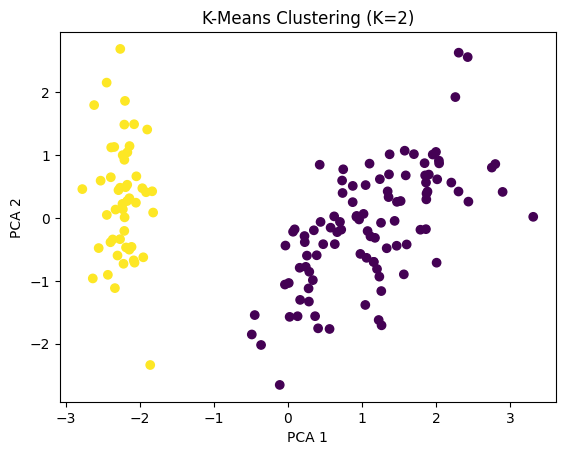

K=3, Distortion=139.82, Silhouette=0.4599


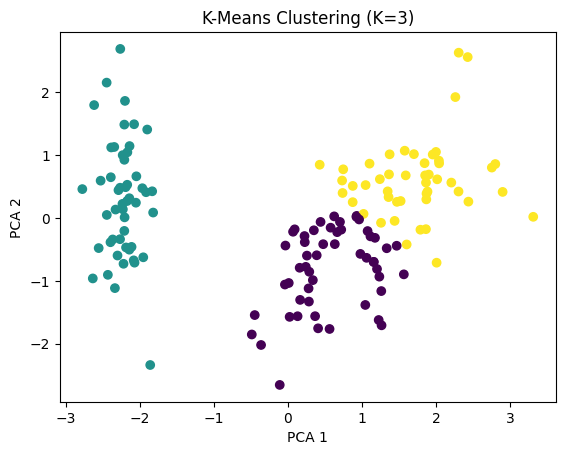

K=4, Distortion=114.09, Silhouette=0.3869


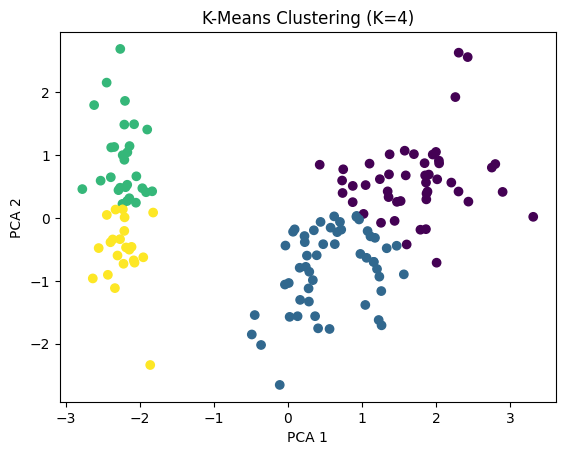

K=5, Distortion=90.93, Silhouette=0.3459


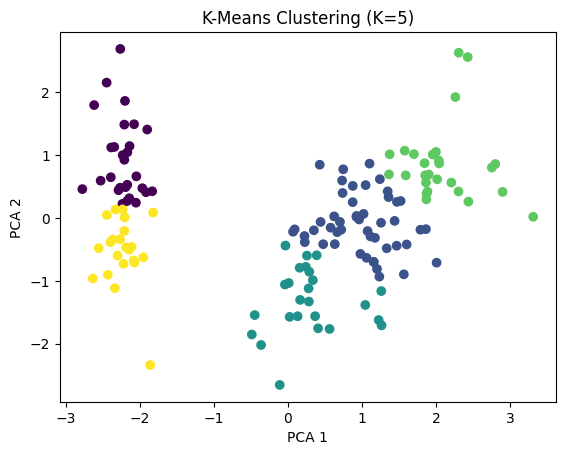

K=6, Distortion=81.54, Silhouette=0.3171


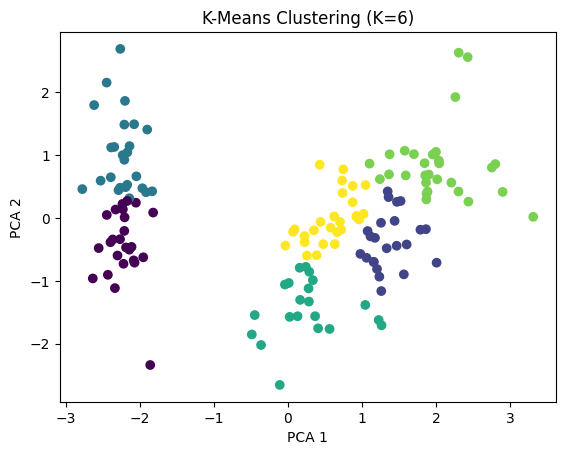

K=7, Distortion=72.63, Silhouette=0.3202


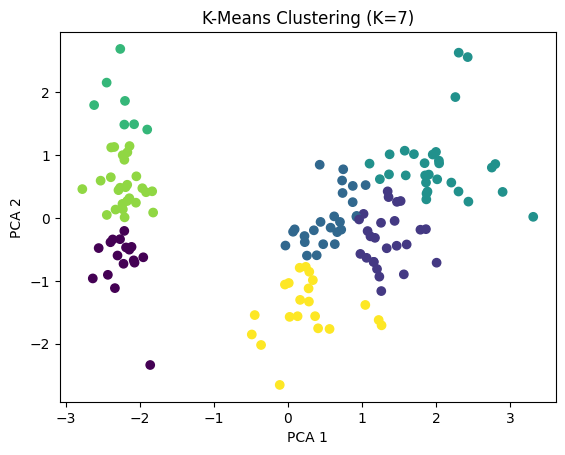

K=8, Distortion=62.54, Silhouette=0.3387


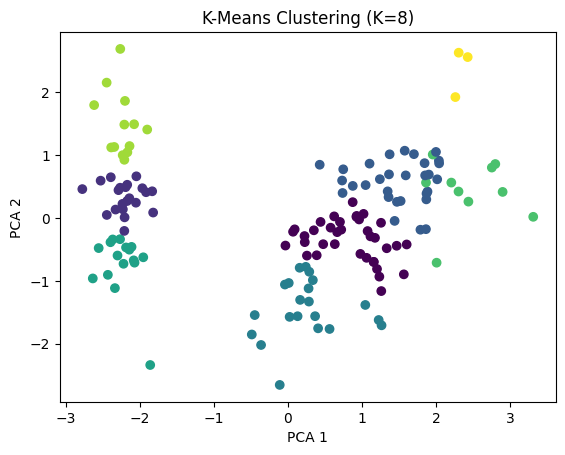

K=9, Distortion=55.12, Silhouette=0.3424


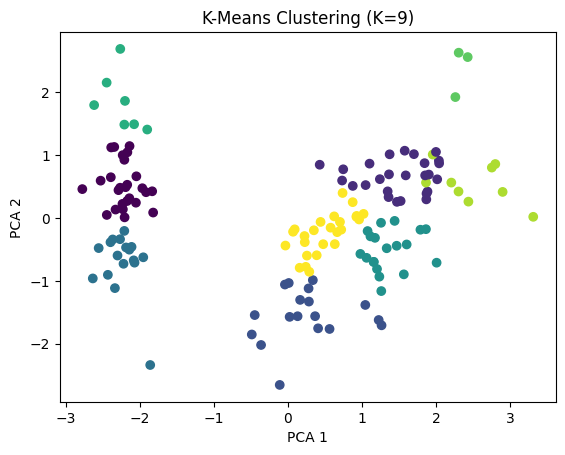

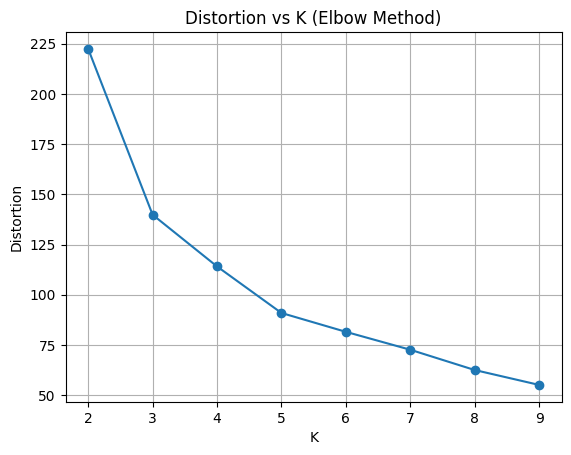

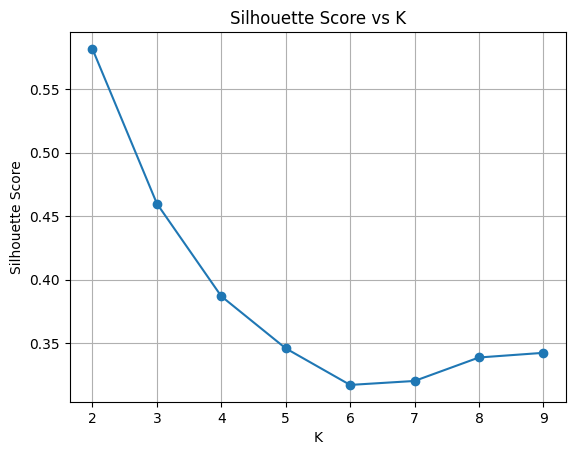


Best K = 2
Best Silhouette Score = 0.5818


In [ ]:
# #Kmeans===============================
# 1. LOAD & PREPROCESS DATA
# ===============================
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data

# Standardize (IMPORTANT for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# ===============================
# 2. IMPORTS
# ===============================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 3. TRY DIFFERENT K VALUES
# ===============================
K_range = range(2, 10)

distortions = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    # Distortion (inertia)
    distortions.append(kmeans.inertia_)

    # Silhouette score
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K={k}, Distortion={kmeans.inertia_:.2f}, Silhouette={score:.4f}")

    # Plot clustering result
    plt.figure()
    plt.title(f"K-Means Clustering (K={k})")
    plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()

# ===============================
# 4. ELBOW METHOD (DISTORTION)
# ===============================
plt.figure()
plt.plot(K_range, distortions, marker='o')
plt.title("Distortion vs K (Elbow Method)")
plt.xlabel("K")
plt.ylabel("Distortion")
plt.grid()
plt.show()

# ===============================
# 5. SILHOUETTE vs K
# ===============================
plt.figure()
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

# ===============================
# 6. BEST K
# ===============================
best_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("\n==============================")
print(f"Best K = {best_k}")
print(f"Best Silhouette Score = {best_score:.4f}")

In [ ]:
#Hierarchal Clustering

Linkage=ward, Metric=euclidean, Score=0.5770


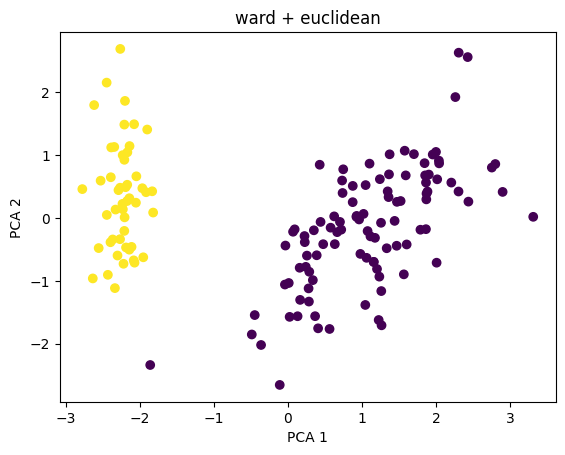

Linkage=complete, Metric=euclidean, Score=0.4408


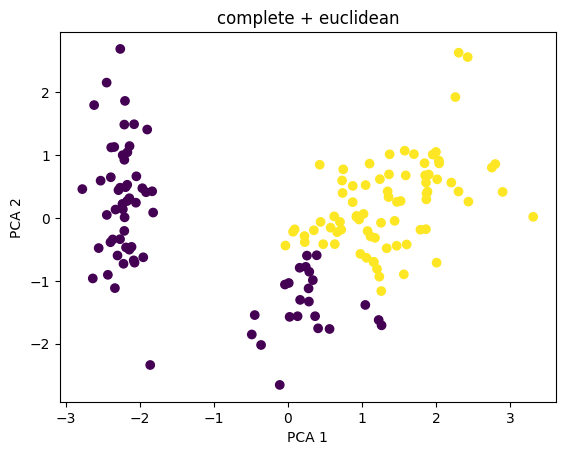

Linkage=complete, Metric=manhattan, Score=0.4302


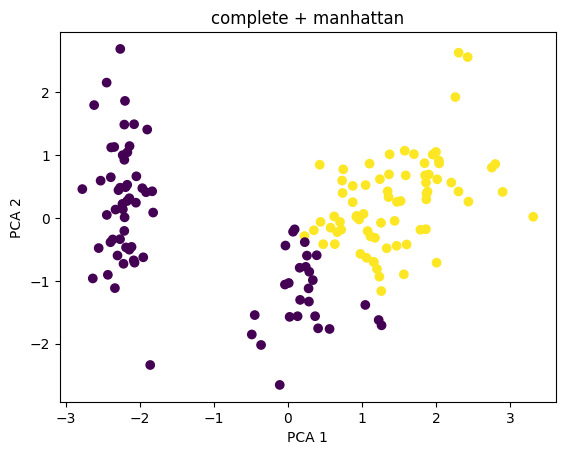

Linkage=complete, Metric=cosine, Score=0.4119


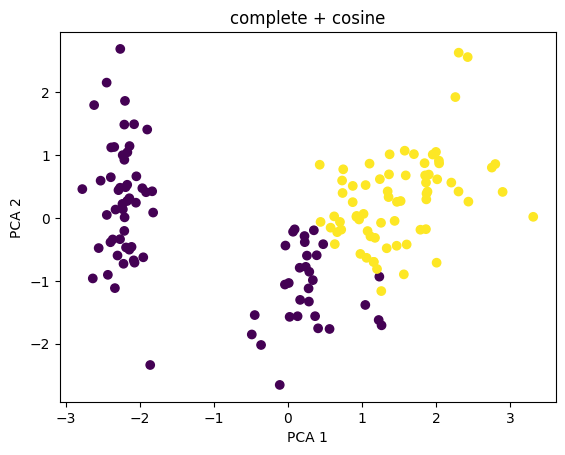

Linkage=average, Metric=euclidean, Score=0.5818


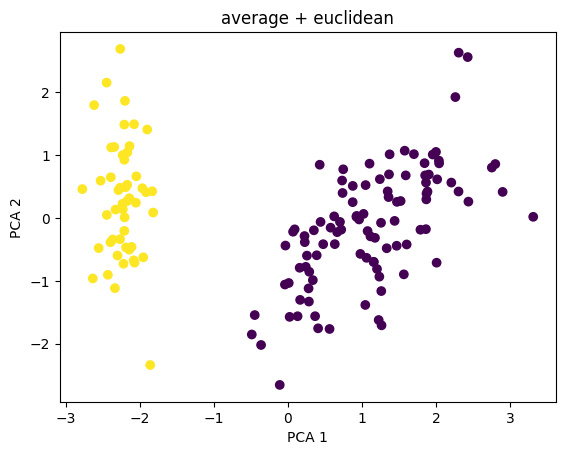

Linkage=average, Metric=manhattan, Score=0.5818


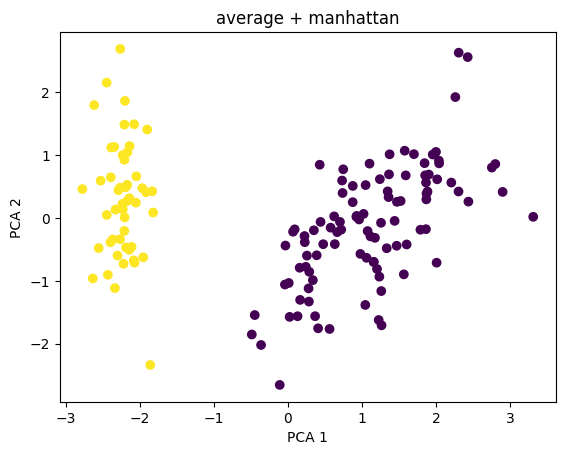

Linkage=average, Metric=cosine, Score=0.5770


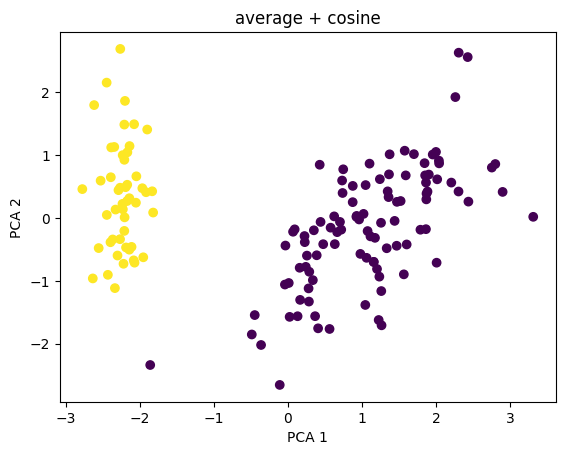


BEST HIERARCHICAL PARAMETERS
Linkage = average
Metric = euclidean
Best Silhouette Score = 0.5818


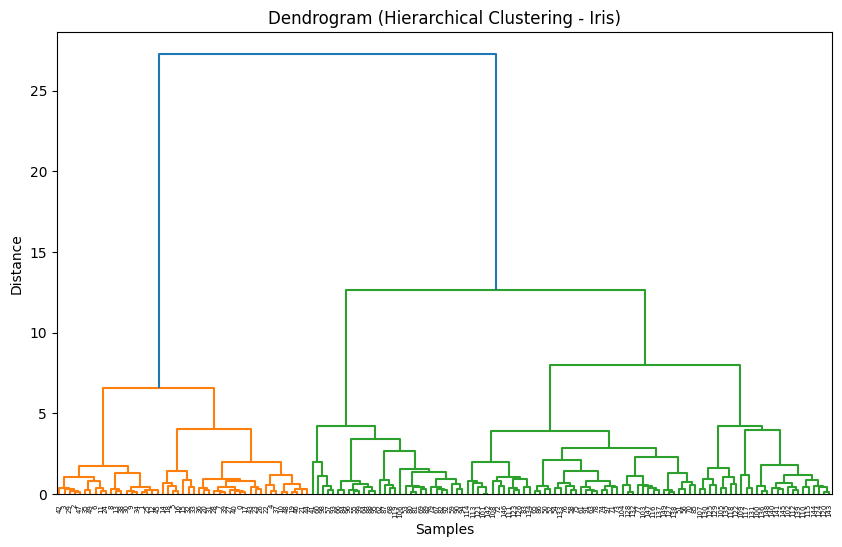

Threshold=3, Clusters=11, Score=0.2990


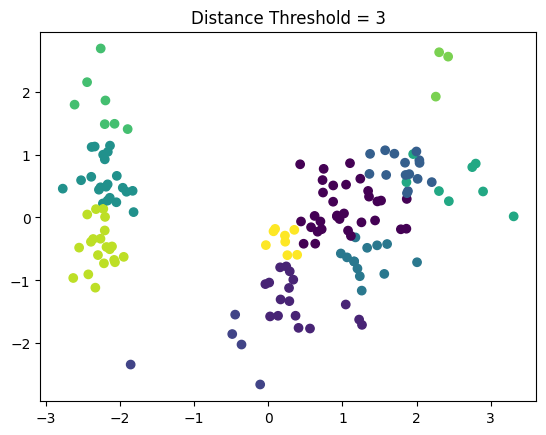

Threshold=5, Clusters=5, Score=0.3306


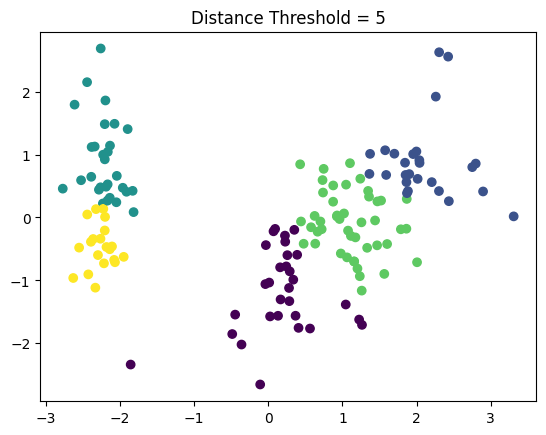

Threshold=7, Clusters=4, Score=0.4006


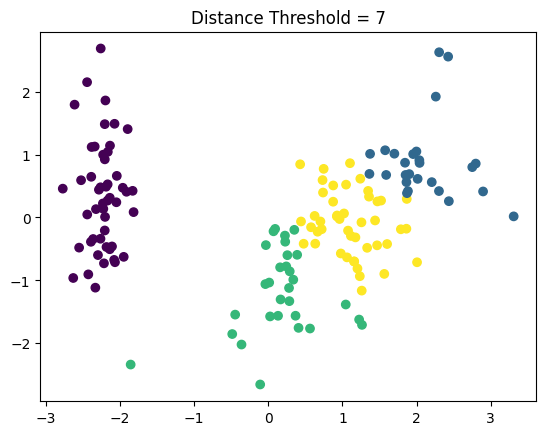

Threshold=10, Clusters=3, Score=0.4467


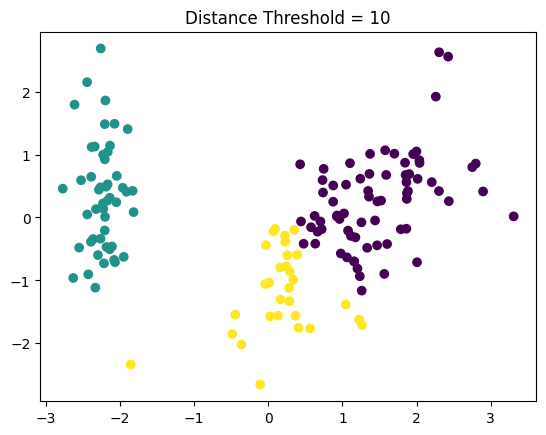

In [ ]:
# ===============================
# 1. LOAD & PREPROCESS
# ===============================
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# ===============================
# 2. IMPORTS
# ===============================
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# 3. TRY DIFFERENT PARAMETERS
# ===============================
linkages = ['ward', 'complete', 'average']
metrics = ['euclidean', 'manhattan', 'cosine']

best_score = -1
best_params = None

results = []

for linkage_method in linkages:
    for metric in metrics:

        # Ward only supports Euclidean
        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        model = AgglomerativeClustering(
            n_clusters=2,  # based on KMeans result
            metric=metric,
            linkage=linkage_method
        )

        labels = model.fit_predict(X_scaled)

        score = silhouette_score(X_scaled, labels)
        results.append((linkage_method, metric, score))

        print(f"Linkage={linkage_method}, Metric={metric}, Score={score:.4f}")

        # Plot clusters
        plt.figure()
        plt.title(f"{linkage_method} + {metric}")
        plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.show()

        if score > best_score:
            best_score = score
            best_params = (linkage_method, metric)

# ===============================
# 4. BEST PARAMETERS
# ===============================
print("\n==============================")
print("BEST HIERARCHICAL PARAMETERS")
print("==============================")
print(f"Linkage = {best_params[0]}")
print(f"Metric = {best_params[1]}")
print(f"Best Silhouette Score = {best_score:.4f}")

# ===============================
# 5. DENDROGRAM (ONE TRIAL)
# ===============================
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title("Dendrogram (Hierarchical Clustering - Iris)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# ===============================
# 6. DISTANCE THRESHOLD TEST
# ===============================
thresholds = [3, 5, 7, 10]

for t in thresholds:
    model = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    if len(set(labels)) > 1:
        score = silhouette_score(X_scaled, labels)
    else:
        score = -1

    print(f"Threshold={t}, Clusters={len(set(labels))}, Score={score:.4f}")

    plt.figure()
    plt.title(f"Distance Threshold = {t}")
    plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
    plt.show()

In [ ]:
#DBSCAN


BEST DBSCAN PARAMETERS
EPS = 1.55
Min_samples = 5
Best Silhouette Score = 0.5818


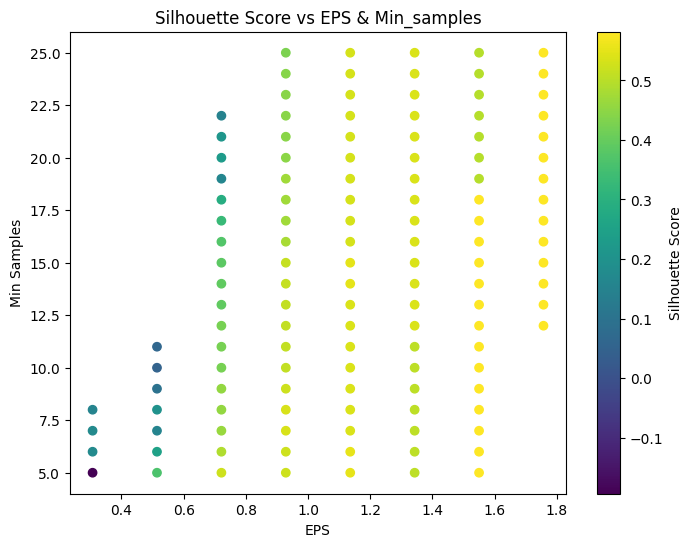

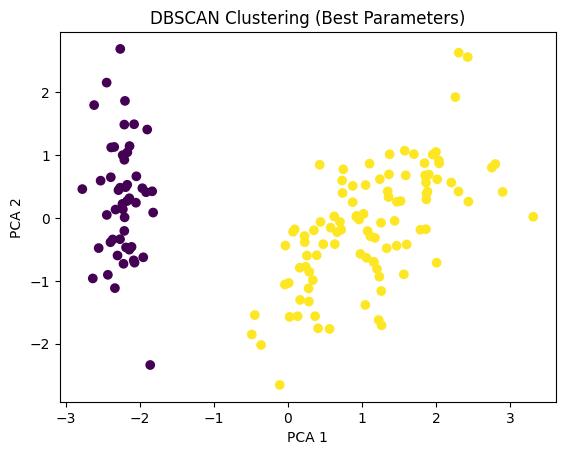

In [ ]:
# ===============================
# DBSCAN ON IRIS (FULL IN ONE CELL)
# ===============================

# 1. Imports
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# 2. Load & preprocess
iris = load_iris()
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# 3. Parameter ranges
eps_values = np.linspace(0.1, 3, 15)
min_samples_values = range(5, 26)

best_score = -1
best_params = None
results = []

# 4. Grid search
for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # Skip invalid cases
        if n_clusters <= 1:
            continue

        score = silhouette_score(X_scaled, labels)
        results.append((eps, min_samples, score))

        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

# 5. Print best result
print("\n==============================")
print("BEST DBSCAN PARAMETERS")
print("==============================")
print(f"EPS = {best_params[0]:.2f}")
print(f"Min_samples = {best_params[1]}")
print(f"Best Silhouette Score = {best_score:.4f}")

# 6. Plot silhouette vs parameters
eps_list = [r[0] for r in results]
min_samples_list = [r[1] for r in results]
scores = [r[2] for r in results]

plt.figure(figsize=(8,6))
scatter = plt.scatter(eps_list, min_samples_list, c=scores)
plt.colorbar(scatter, label="Silhouette Score")
plt.xlabel("EPS")
plt.ylabel("Min Samples")
plt.title("Silhouette Score vs EPS & Min_samples")
plt.show()

# 7. Plot best clustering result
best_model = DBSCAN(eps=best_params[0], min_samples=best_params[1])
labels = best_model.fit_predict(X_scaled)

plt.figure()
plt.title("DBSCAN Clustering (Best Parameters)")
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

## Customer dataset
Repeat all the above on the customer data set

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customer data.csv to Customer data (1).csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("Customer data.csv")

# Drop the ID column
df = df.drop(columns=["ID"])

# Verify
print(df.head())

   Sex  Marital status  Age  Education  Income  Occupation  Settlement size
0    0               0   67          2  124670           1                2
1    1               1   22          1  150773           1                2
2    0               0   49          1   89210           0                0
3    0               0   45          1  171565           1                1
4    0               0   53          1  149031           1                1


K = 2 | Distortion = 10674.29 | Silhouette = 0.2514
K = 3 | Distortion = 8907.90 | Silhouette = 0.2312
K = 4 | Distortion = 7761.47 | Silhouette = 0.2164
K = 5 | Distortion = 6449.49 | Silhouette = 0.2495
K = 6 | Distortion = 5988.10 | Silhouette = 0.2465
K = 7 | Distortion = 5705.05 | Silhouette = 0.2520
K = 8 | Distortion = 5066.32 | Silhouette = 0.2738
K = 9 | Distortion = 4754.75 | Silhouette = 0.2814
K = 10 | Distortion = 4465.75 | Silhouette = 0.2951


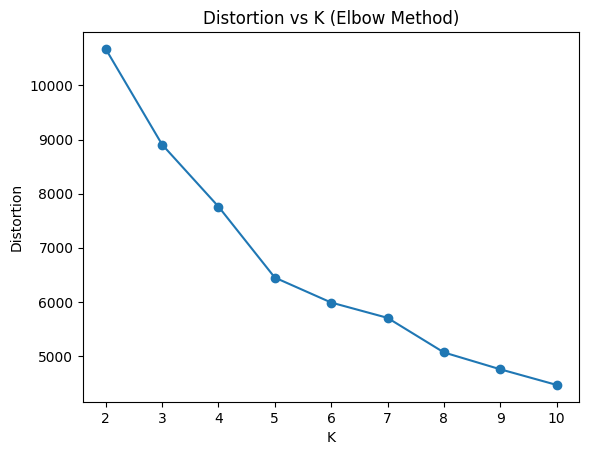

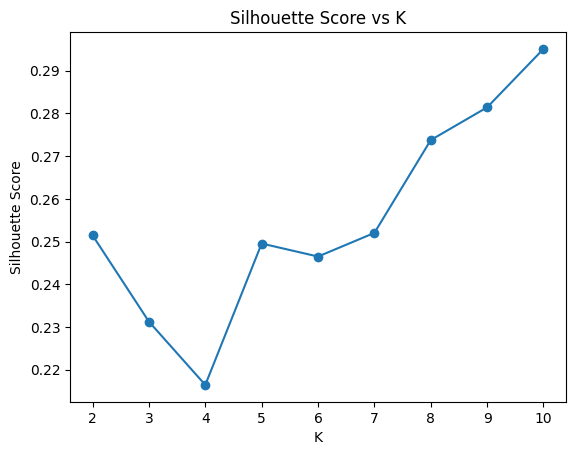


Best K = 10
Best Silhouette Score = 0.2951


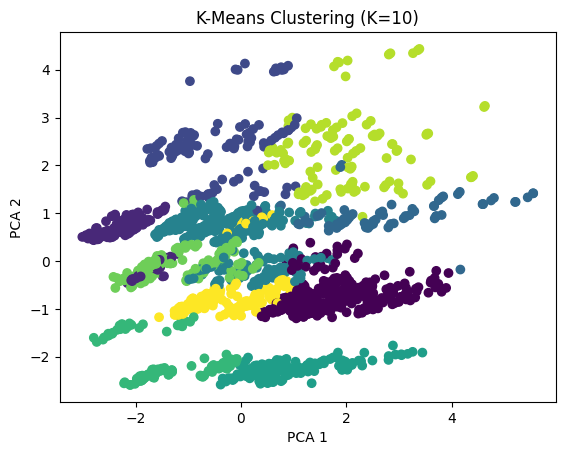

In [ ]:
# ===============================
# K-MEANS ON CUSTOMER DATA (FULL)
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("Customer data.csv")

# Remove ID column
df = df.drop(columns=["ID"], errors='ignore')

# Keep only numeric columns (important!)
df = df.select_dtypes(include=[np.number])

# ===============================
# 2. SCALING (VERY IMPORTANT)
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ===============================
# 3. TRY DIFFERENT K VALUES
# ===============================
K_range = range(2, 11)

distortions = []
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Distortion (inertia)
    distortions.append(kmeans.inertia_)

    # Silhouette
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

    print(f"K = {k} | Distortion = {kmeans.inertia_:.2f} | Silhouette = {score:.4f}")

# ===============================
# 4. ELBOW METHOD
# ===============================
plt.figure()
plt.plot(K_range, distortions, marker='o')
plt.title("Distortion vs K (Elbow Method)")
plt.xlabel("K")
plt.ylabel("Distortion")
plt.show()

# ===============================
# 5. SILHOUETTE VS K
# ===============================
plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

# ===============================
# 6. BEST K
# ===============================
best_k = K_range[np.argmax(sil_scores)]
best_score = max(sil_scores)

print("\n==============================")
print(f"Best K = {best_k}")
print(f"Best Silhouette Score = {best_score:.4f}")

# ===============================
# 7. FINAL MODEL
# ===============================
kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# ===============================
# 8. VISUALIZATION (PCA)
# ===============================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

plt.figure()
plt.title(f"K-Means Clustering (K={best_k})")
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Linkage=ward, Metric=euclidean, Score=0.2493


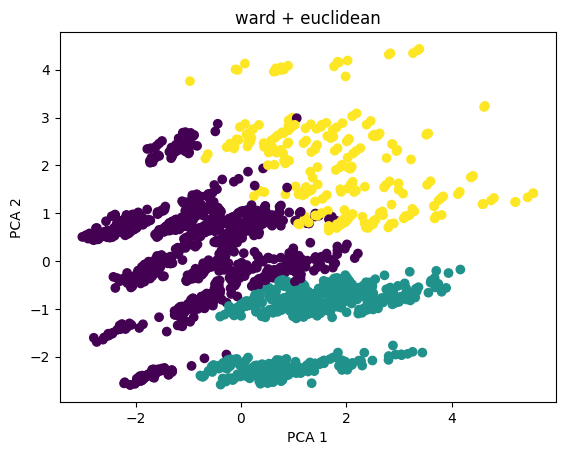

Linkage=complete, Metric=euclidean, Score=0.1312


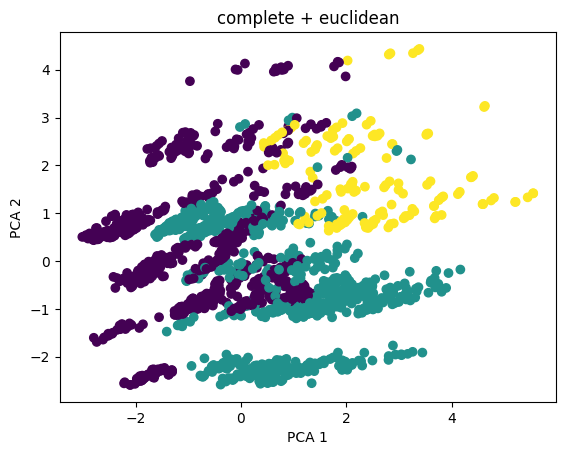

Linkage=complete, Metric=manhattan, Score=0.2150


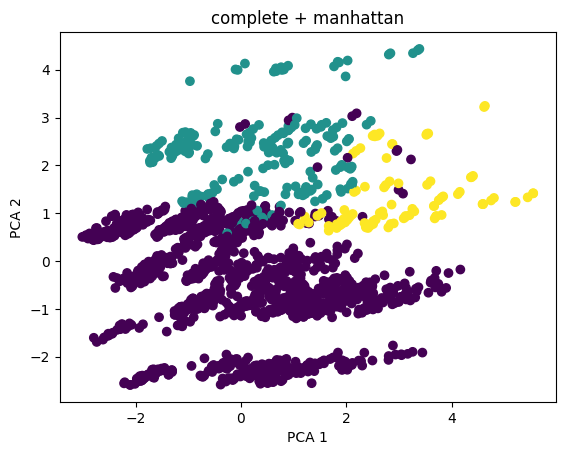

Linkage=complete, Metric=cosine, Score=0.1896


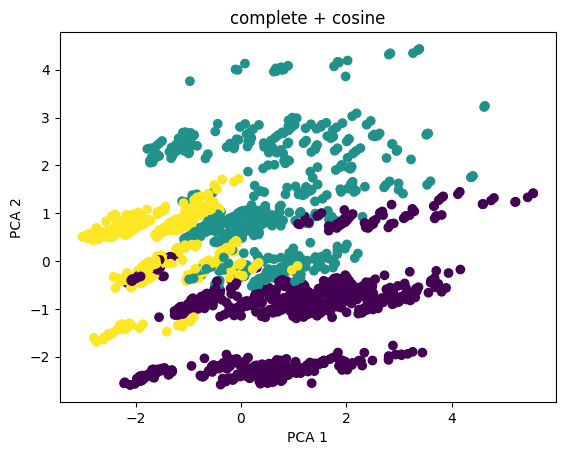

Linkage=average, Metric=euclidean, Score=0.2551


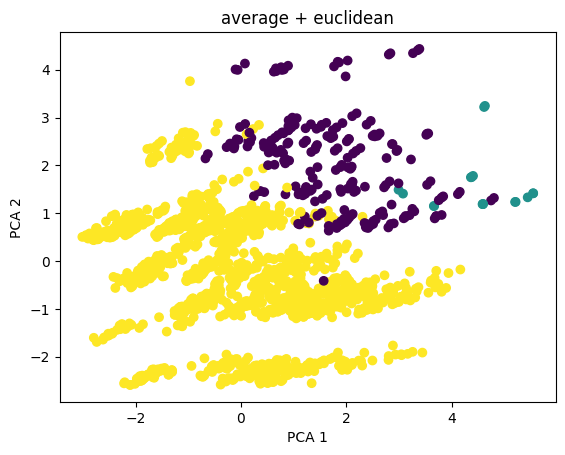

Linkage=average, Metric=manhattan, Score=0.2635


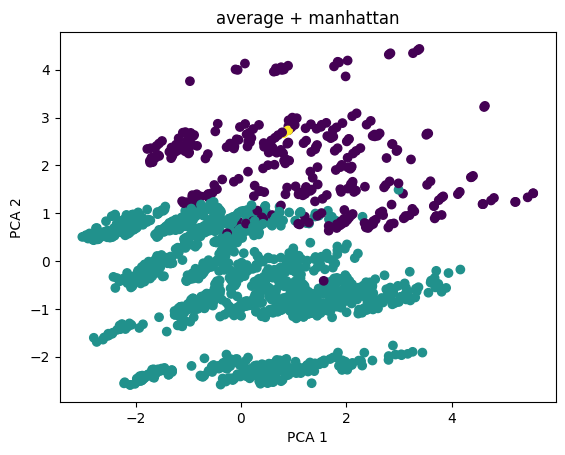

Linkage=average, Metric=cosine, Score=0.2573


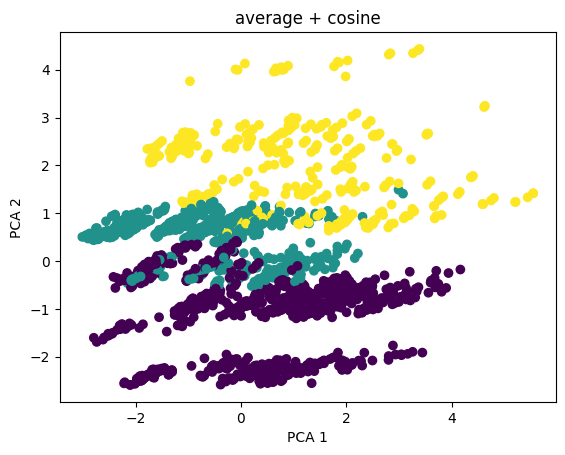


BEST HIERARCHICAL PARAMETERS
Linkage = average
Metric = manhattan
Best Silhouette Score = 0.2635


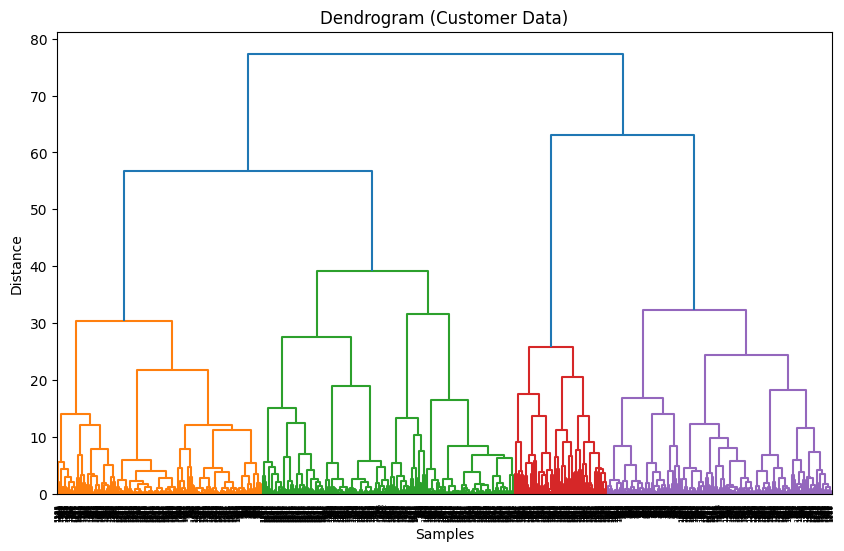

Threshold=5 | Clusters=71 | Score=0.4244


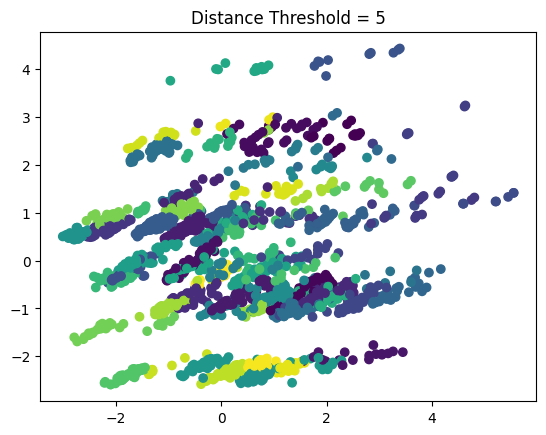

Threshold=10 | Clusters=32 | Score=0.4184


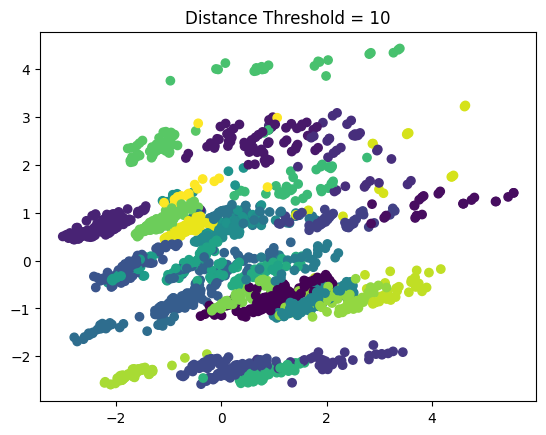

Threshold=15 | Clusters=19 | Score=0.3511


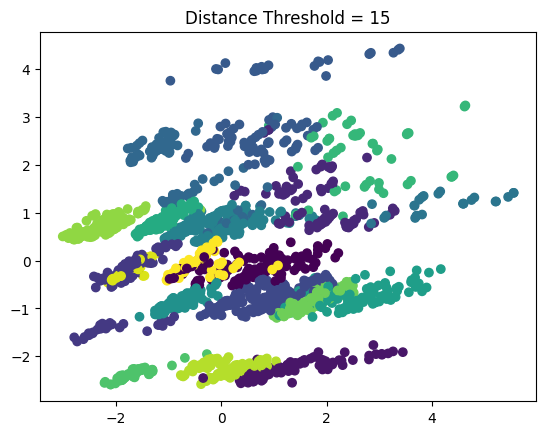

Threshold=20 | Clusters=13 | Score=0.3036


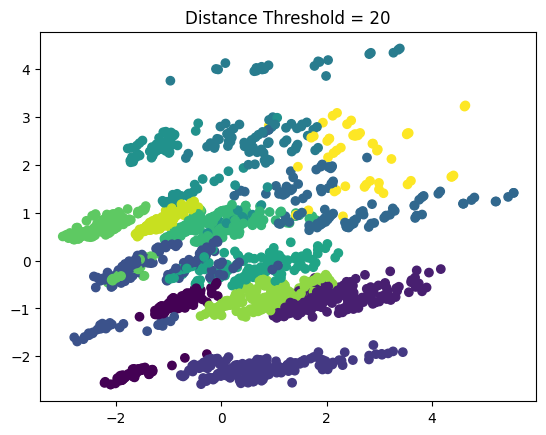

In [ ]:
# =========================================
# HIERARCHICAL CLUSTERING (CUSTOMER DATA)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("Customer data.csv")

# Remove ID
df = df.drop(columns=["ID"], errors='ignore')

# Keep numeric only
df = df.select_dtypes(include=[np.number])

# ===============================
# 2. SCALING
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA for visualization
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# ===============================
# 3. PARAMETER SEARCH
# ===============================
linkages = ['ward', 'complete', 'average']
metrics = ['euclidean', 'manhattan', 'cosine']

best_score = -1
best_params = None

for linkage_method in linkages:
    for metric in metrics:

        # Ward only works with Euclidean
        if linkage_method == 'ward' and metric != 'euclidean':
            continue

        model = AgglomerativeClustering(
            n_clusters=3,  # you can change based on KMeans result
            metric=metric,
            linkage=linkage_method
        )

        labels = model.fit_predict(X_scaled)

        if len(set(labels)) <= 1:
            continue

        score = silhouette_score(X_scaled, labels)

        print(f"Linkage={linkage_method}, Metric={metric}, Score={score:.4f}")

        # Plot clusters
        plt.figure()
        plt.title(f"{linkage_method} + {metric}")
        plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.show()

        if score > best_score:
            best_score = score
            best_params = (linkage_method, metric)

# ===============================
# 4. BEST PARAMETERS
# ===============================
print("\n==============================")
print("BEST HIERARCHICAL PARAMETERS")
print("==============================")
print(f"Linkage = {best_params[0]}")
print(f"Metric = {best_params[1]}")
print(f"Best Silhouette Score = {best_score:.4f}")

# ===============================
# 5. DENDROGRAM (ONE TRIAL)
# ===============================
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram (Customer Data)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

# ===============================
# 6. DISTANCE THRESHOLD TEST
# ===============================
thresholds = [5, 10, 15, 20]

for t in thresholds:
    model = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=t,
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels))

    if n_clusters > 1:
        score = silhouette_score(X_scaled, labels)
    else:
        score = -1

    print(f"Threshold={t} | Clusters={n_clusters} | Score={score:.4f}")

    plt.figure()
    plt.title(f"Distance Threshold = {t}")
    plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
    plt.show()


BEST DBSCAN PARAMETERS
EPS = 1.14
Min_samples = 5
Best Silhouette Score = 0.4159


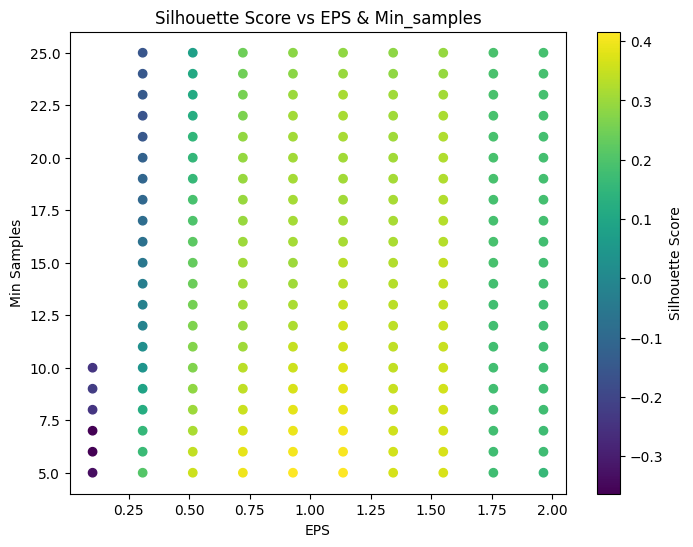

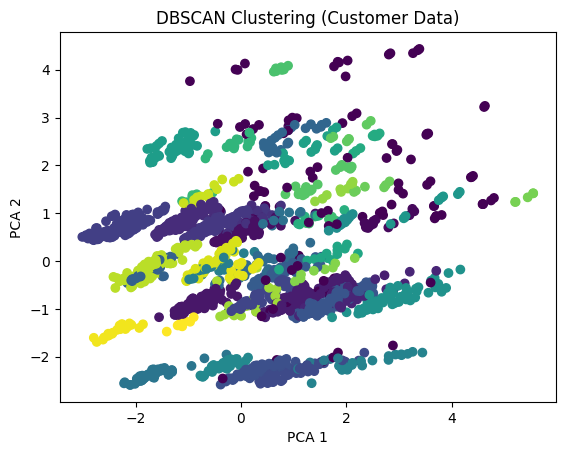

In [ ]:
# =========================================
# DBSCAN (CUSTOMER DATA - FULL CELL)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("Customer data.csv")

# Remove ID column
df = df.drop(columns=["ID"], errors='ignore')

# Keep numeric only
df = df.select_dtypes(include=[np.number])

# ===============================
# 2. SCALING
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA for visualization
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X_scaled)

# ===============================
# 3. PARAMETER SEARCH
# ===============================
eps_values = np.linspace(0.1, 3, 15)
min_samples_values = range(5, 26)

best_score = -1
best_params = None
results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)

        # Count clusters (ignore noise -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters <= 1:
            continue

        score = silhouette_score(X_scaled, labels)
        results.append((eps, min_samples, score))

        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

# ===============================
# 4. BEST PARAMETERS
# ===============================
print("\n==============================")
print("BEST DBSCAN PARAMETERS")
print("==============================")
print(f"EPS = {best_params[0]:.2f}")
print(f"Min_samples = {best_params[1]}")
print(f"Best Silhouette Score = {best_score:.4f}")

# ===============================
# 5. SILHOUETTE vs PARAMETERS
# ===============================
eps_list = [r[0] for r in results]
min_samples_list = [r[1] for r in results]
scores = [r[2] for r in results]

plt.figure(figsize=(8,6))
scatter = plt.scatter(eps_list, min_samples_list, c=scores)
plt.colorbar(scatter, label="Silhouette Score")
plt.xlabel("EPS")
plt.ylabel("Min Samples")
plt.title("Silhouette Score vs EPS & Min_samples")
plt.show()

# ===============================
# 6. PLOT BEST CLUSTERS
# ===============================
best_model = DBSCAN(eps=best_params[0], min_samples=best_params[1])
labels = best_model.fit_predict(X_scaled)

plt.figure()
plt.title("DBSCAN Clustering (Customer Data)")
plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()